In [7]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#109747'
NONTARGET_COLOR = 'black'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [28]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 2c.csv'))

In [29]:
df

,Unnamed: 0,animal,session,cluster ID,learning phase,target rate,nontarget rate
0,0,BS_108,BS_108_1_AC.pickle,2,pre expert,16.825397,3.218391
1,1,BS_108,BS_108_1_AC.pickle,8,pre expert,30.937500,12.000000
2,2,BS_108,BS_108_1_AC.pickle,9,pre expert,24.062500,7.000000
3,3,BS_108,BS_108_1_AC.pickle,14,pre expert,18.306878,2.988506
4,4,BS_108,BS_108_1_AC.pickle,34,pre expert,26.250000,7.111111
...,...,...,...,...,...,...,...
1358,1358,DS_19,DS_19_1_AC.pickle,96,pre expert,4.072250,1.880342
1359,1359,DS_19,DS_19_1_AC.pickle,106,pre expert,-1.643411,-2.147436
1360,1360,DS_19,DS_19_20_AC.pickle,7,post expert,10.069444,-2.886598
1361,1361,DS_19,DS_19_20_AC.pickle,8,post expert,-2.986111,-2.955326


In [5]:
Tuning_target_preearly = []
Tuning_target_prelate = []
Tuning_target_preexpert = []
Tuning_target_postearly = []
Tuning_target_postlate = []
Tuning_target_postexpert = []

Tuning_nontarget_preearly = []
Tuning_nontarget_prelate = []
Tuning_nontarget_preexpert = []
Tuning_nontarget_postearly = []
Tuning_nontarget_postlate = []
Tuning_nontarget_postexpert = []

for row in df.iloc:
    if row['learning phase'] == 'pre early':
        Tuning_target_preearly.append(row['target rate'])
        Tuning_nontarget_preearly.append(row['nontarget rate'])
    if row['learning phase'] == 'pre late':
        Tuning_target_prelate.append(row['target rate'])
        Tuning_nontarget_prelate.append(row['nontarget rate'])
    if row['learning phase'] == 'pre expert':
        Tuning_target_preexpert.append(row['target rate'])
        Tuning_nontarget_preexpert.append(row['nontarget rate'])
        
    if row['learning phase'] == 'post early':
        Tuning_target_postearly.append(row['target rate'])
        Tuning_nontarget_postearly.append(row['nontarget rate'])
    if row['learning phase'] == 'post late':
        Tuning_target_postlate.append(row['target rate'])
        Tuning_nontarget_postlate.append(row['nontarget rate'])
    if row['learning phase'] == 'post expert':
        Tuning_target_postexpert.append(row['target rate'])
        Tuning_nontarget_postexpert.append(row['nontarget rate'])

Tuning_target_preearly = np.array(ilep.rmnan(Tuning_target_preearly))
Tuning_target_prelate = np.array(ilep.rmnan(Tuning_target_prelate))
Tuning_target_preexpert = np.array(ilep.rmnan(Tuning_target_preexpert))
Tuning_target_postearly = np.array(ilep.rmnan(Tuning_target_postearly))
Tuning_target_postlate = np.array(ilep.rmnan(Tuning_target_postlate))
Tuning_target_postexpert = np.array(ilep.rmnan(Tuning_target_postexpert))

Tuning_nontarget_preearly = np.array(ilep.rmnan(Tuning_nontarget_preearly))
Tuning_nontarget_prelate = np.array(ilep.rmnan(Tuning_nontarget_prelate))
Tuning_nontarget_preexpert = np.array(ilep.rmnan(Tuning_nontarget_preexpert))
Tuning_nontarget_postearly = np.array(ilep.rmnan(Tuning_nontarget_postearly))
Tuning_nontarget_postlate = np.array(ilep.rmnan(Tuning_nontarget_postlate))
Tuning_nontarget_postexpert = np.array(ilep.rmnan(Tuning_nontarget_postexpert))

8.512705941978854
4.52161905274856
7.860508890062039
6.979274654527592
2.0733163840171365
3.8064482556066475
306
342


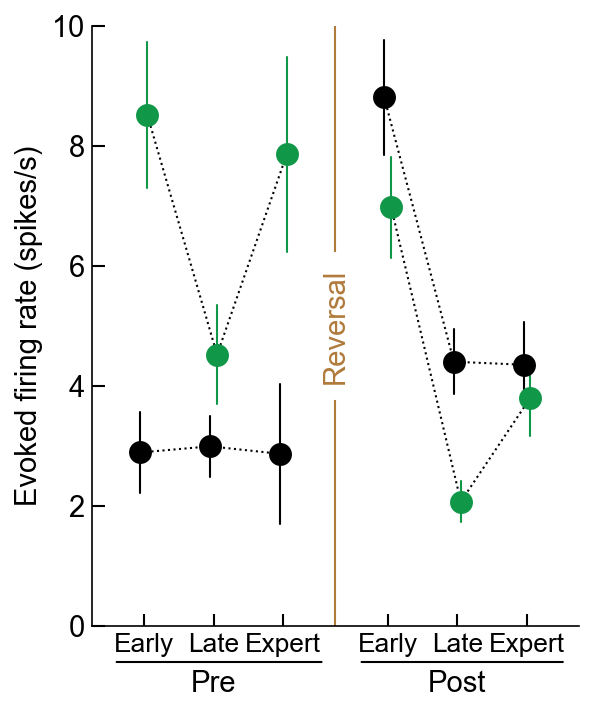

In [8]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3.25, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25
offset_distance = 0.05

################################################################################################################

data = [Tuning_target_preearly,Tuning_target_prelate,Tuning_target_preexpert,Tuning_target_postearly,Tuning_target_postlate,Tuning_target_postexpert]
data = [ilep.rmnan(d) for d in data]
#Plot summary
colmaxes = [np.nan]*6
for idx,(column,polarity) in enumerate(zip(data,[-1,-1,-1,1,1,1])):
    eye_color = TARGET_COLOR
    border_color=eye_color
    summary_size=100
    summary_width=1

    median = np.mean(column)
    print(median)
    Q1 = median - sem(column)
    Q3 = median + sem(column)
    colmaxes[idx] = Q3
    
    ax.scatter([idx+offset_distance+polarity*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, zorder=10)
    ax.plot([idx+offset_distance+polarity*switch_offset, idx+offset_distance+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    
medians = [np.mean(col) for col in data]
plt.plot(np.linspace(0,2,3)+offset_distance-switch_offset,medians[0:3],color='k',linestyle=':',lw=1)
plt.plot(np.linspace(3,5,3)+offset_distance+switch_offset,medians[3:6],color='k',linestyle=':',lw=1)
    
########################################################
data_two = [Tuning_nontarget_preearly,Tuning_nontarget_prelate,Tuning_nontarget_preexpert,Tuning_nontarget_postearly,Tuning_nontarget_postlate,Tuning_nontarget_postexpert]
data_two = [ilep.rmnan(d) for d in data_two]

#Plot summary
passive_colmaxes = [np.nan]*6
for idx,(column,polarity) in enumerate(zip(data_two,[-1,-1,-1,1,1,1])):
    border_color=NONTARGET_COLOR
    eye_color=border_color

    summary_size=100
    summary_width=1
    median = np.mean(column)
    Q1 = median - sem(column)
    Q3 = median + sem(column)
    passive_colmaxes[idx] = Q3
    
    ax.scatter([idx-offset_distance+polarity*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, zorder=10,marker='o')
    ax.plot([idx-offset_distance+polarity*switch_offset, idx-offset_distance+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    
medians = [np.mean(col) for col in data_two]
plt.plot(np.linspace(0,2,3)-offset_distance-switch_offset,medians[0:3],color='k',linestyle=':',lw=1)
plt.plot(np.linspace(3,5,3)-offset_distance+switch_offset,medians[3:6],color='k',linestyle=':',lw=1)

################################################################################################################

labels = ['Early','Late','Expert','Early','Late','Expert']

ax.set_ylim([0,10])
ylab = ax.set_ylabel('Evoked firing rate (spikes/s)')
              
ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)

xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.0425, -stdyfrac), xycoords='axes fraction', xytext=(0.48, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.545, -stdyfrac), xycoords='axes fraction', xytext=(0.975, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

ax.scatter([], [], ec=TARGET_COLOR,fc=TARGET_COLOR, s=summary_size,lw=summary_width,marker='o',label='Target')
ax.scatter([], [], ec=NONTARGET_COLOR,fc=NONTARGET_COLOR, s=summary_size,lw=summary_width,marker='o',label='Nontarget')

### Linear
Y = np.mean(ax.get_ylim())
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,t2]


# fig.savefig(os.path.join('..','..','Figures','Figure 2c.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [9]:
data = SimpleNamespace()
data.preearly = Tuning_target_preearly
data.prelate = Tuning_target_prelate 
data.preexpert = Tuning_target_preexpert
data.postearly = Tuning_target_postearly
data.postlate = Tuning_target_postlate
data.postexpert = Tuning_target_postexpert


ilep.mannwhitneycompareall(data)

pre-early   n = 148
pre-late    n = 187
pre-expert  n = 97
post-early  n = 306
post-late   n = 342
post-expert n = 247
pre-early  to pre-late   : 0.000792283588036471
pre-late   to pre-expert : 0.16596869991458363
pre-early  to pre-expert : 0.16596869991458363
post-early to post-late  : 7.539424281353399e-07
post-late  to post-expert: 0.03723416084350049
post-early to post-expert: 0.02510120845294397


In [26]:
data = SimpleNamespace()
data.preearly = Tuning_nontarget_preearly
data.prelate = Tuning_nontarget_prelate 
data.preexpert = Tuning_nontarget_preexpert
data.postearly = Tuning_nontarget_postearly
data.postlate = Tuning_nontarget_postlate
data.postexpert = Tuning_nontarget_postexpert


ilep.mannwhitneycompareall(data)

pre-early   n = 148
pre-late    n = 187
pre-expert  n = 97
post-early  n = 306
post-late   n = 342
post-expert n = 247
pre-early  to pre-late   : 0.3985826432073604
pre-late   to pre-expert : 0.3985826432073604
pre-early  to pre-expert : 0.8922249724401682
post-early to post-late  : 4.582830552280292e-05
post-late  to post-expert: 0.9700564923784906
post-early to post-expert: 6.496954532022818e-05


In [27]:
p1 = ttest_ind(Tuning_target_preearly,Tuning_target_prelate,equal_var=True).pvalue
p2 = ttest_ind(Tuning_target_preearly,Tuning_target_preexpert,equal_var=True).pvalue
p3 = ttest_ind(Tuning_target_prelate,Tuning_target_preexpert,equal_var=True).pvalue
p4 = ttest_ind(Tuning_target_postearly,Tuning_target_postlate,equal_var=True).pvalue
p5 = ttest_ind(Tuning_target_postearly,Tuning_target_postexpert,equal_var=True).pvalue
p6 = ttest_ind(Tuning_target_postlate,Tuning_target_postexpert,equal_var=True).pvalue

pvals = [p1,p2,p3,p4,p5,p6]
# pvals = [p1,p2,p3]

_,pvals_corr = pg.multicomp(pvals,method='fdr_bh')
print(f'early to late   : {pvals_corr[0]}')
print(f'early to expert : {pvals_corr[1]}')
print(f'late to expert  : {pvals_corr[2]}\n')

print(f'early to late   : {pvals_corr[3]}')
print(f'early to expert : {pvals_corr[4]}')
print(f'late to expert  : {pvals_corr[5]}')

early to late   : 0.013965299234361265
early to expert : 0.7482386058594144
late to expert  : 0.08235728648440845

early to late   : 6.465160346906656e-07
early to expert : 0.007977221161268864
late to expert  : 0.02515701323693546


In [25]:
p1 = ttest_ind(Tuning_nontarget_preearly,Tuning_nontarget_prelate,equal_var=True).pvalue
p2 = ttest_ind(Tuning_nontarget_preearly,Tuning_nontarget_preexpert,equal_var=True).pvalue
p3 = ttest_ind(Tuning_nontarget_prelate,Tuning_nontarget_preexpert,equal_var=True).pvalue
p4 = ttest_ind(Tuning_nontarget_postearly,Tuning_nontarget_postlate,equal_var=True).pvalue
p5 = ttest_ind(Tuning_nontarget_postearly,Tuning_nontarget_postexpert,equal_var=True).pvalue
p6 = ttest_ind(Tuning_nontarget_postlate,Tuning_nontarget_postexpert,equal_var=True).pvalue

pvals = [p1,p2,p3,p4,p5,p6]
# pvals = [p1,p2,p3]

_,pvals_corr = pg.multicomp(pvals,method='fdr_bh')
print(f'early to late   : {pvals_corr[0]}')
print(f'early to expert : {pvals_corr[1]}')
print(f'late to expert  : {pvals_corr[2]}\n')

print(f'early to late   : {pvals_corr[3]}')
print(f'early to expert : {pvals_corr[4]}')
print(f'late to expert  : {pvals_corr[5]}')

early to late   : 0.9858092441915028
early to expert : 0.9858092441915028
late to expert  : 0.9858092441915028

early to late   : 0.000259045038581701
early to expert : 0.0010622064883778928
late to expert  : 0.9858092441915028
